In [115]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt 

In [117]:
from rnn_utils import ALL_LETTERS, N_LETTERS
from rnn_utils import load_data, letter_to_tensor, line_to_tensor, random_training_example

In [119]:
import torch
import torch.nn as nn

class RNN(nn.Module):
    # Inicjalizujemy rozmiary naszej sieci
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        # WARSTWY (WAGI SIECI)
        # Tworzymy dwie oddzielne warstwy liniowe. 
        # Zauważ, że ich wejściem jest połączony rozmiar wejścia i stanu ukrytego!
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        
        # Funkcja aktywacji na końcu, aby zamienić surowe wyniki w prawdopodobieństwa
        self.softmax = nn.LogSoftmax(dim=1)

    # Definiujemy przepływ danych w pojedynczym kroku czasowym
    def forward(self, input, hidden):
        # 1. ŁĄCZENIE (KONKATENACJA)
        # Sklejamy wektor obecnego znaku (input) z wektorem pamięci (hidden)
        # Argument '1' oznacza łączenie wzdłuż wymiaru cech.
        combined = torch.cat((input, hidden), 1)

        # 2. OBLICZENIE NOWEGO STANU UKRYTEGO
        # Przepuszczamy sklejony wektor przez warstwę i2h (Input to Hidden)
        hidden = self.i2h(combined)

        # 3. OBLICZENIE WYJŚCIA
        # Przepuszczamy ten sam sklejony wektor przez warstwę i2o (Input to Output)
        output = self.i2o(combined)
        output = self.softmax(output)
        
        # Zwracamy ZARÓWNO wyjście, jak i nowy stan ukryty, by użyć ich w kolejnej iteracji
        return output, hidden

    def init_hidden(self):
        # Funkcja pomocnicza: tworzy pusty wektor zer dla stanu h_0
        return torch.zeros(1, self.hidden_size)

In [121]:
category_lines, all_categories = load_data()
n_categories = len(all_categories)
n_categories

18

In [123]:
n_hidden = 128
rnn = RNN(N_LETTERS, n_hidden, n_categories)

In [153]:
# one step
input_tensor = letter_to_tensor('A')
hidden_tensor = rnn.init_hidden()
input_tensor
input_tensor.size()

torch.Size([1, 57])

In [127]:
output, next_hidden = rnn(input_tensor, hidden_tensor)
print(output.size())
print(next_hidden.size())

torch.Size([1, 18])
torch.Size([1, 128])


In [151]:
# whole sequence/name
input_tensor = line_to_tensor('Albert')
hidden_tensor = rnn.init_hidden()
input_tensor.size()

torch.Size([6, 1, 57])

In [131]:
output, next_hidden = rnn(input_tensor[0], hidden_tensor)
print(output.size())
print(next_hidden.size())

torch.Size([1, 18])
torch.Size([1, 128])


In [133]:
def category_from_output(output):
    category_idx = torch.argmax(output).item()
    return all_categories[category_idx]

print(category_from_output(output))

Vietnamese


In [135]:
criterion = nn.NLLLoss()
learning_rate = 0.005
optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

In [137]:
def train(line_tensor, category_tensor):
    hidden = rnn.init_hidden()
    
    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
        
    loss = criterion(output, category_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return output, loss.item()

In [139]:
current_loss = 0
all_losses = []
plot_steps, print_steps = 1000, 5000
n_iters = 100000
for i in range(n_iters):
    category, line, category_tensor, line_tensor = random_training_example(category_lines, all_categories)
    
    output, loss = train(line_tensor, category_tensor)
    current_loss += loss 
    
    if (i+1) % plot_steps == 0:
        all_losses.append(current_loss / plot_steps)
        current_loss = 0
        
    if (i+1) % print_steps == 0:
        guess = category_from_output(output)
        correct = "CORRECT" if guess == category else f"WRONG ({category})"
        print(f"{i+1} {(i+1)/n_iters*100} {loss:.4f} {line} / {guess} {correct}")

5000 5.0 2.1518 Estevez / Spanish CORRECT
10000 10.0 1.7251 Paredes / Portuguese CORRECT
15000 15.0 2.3976 Siagyo / Portuguese WRONG (Japanese)
20000 20.0 1.6310 Moy / Korean WRONG (Chinese)
25000 25.0 0.9029 Castro / Portuguese CORRECT
30000 30.0 0.0501 Konstantatos / Greek CORRECT
35000 35.0 0.8572 Faolan / Irish CORRECT
40000 40.0 1.2255 Reinders / Dutch CORRECT
45000 45.0 0.0745 Mujkaterov / Russian CORRECT
50000 50.0 0.9041 Westerberg / German CORRECT
55000 55.00000000000001 0.6790 Song / Korean CORRECT
60000 60.0 1.4513 Kouches / Greek CORRECT
65000 65.0 0.2738 Gan / Chinese CORRECT
70000 70.0 0.4257 Wawrzaszek / Polish CORRECT
75000 75.0 2.7321 Nugent / French WRONG (English)
80000 80.0 2.0901 Bonnay / Irish WRONG (French)
85000 85.0 1.1438 Durylin / Russian CORRECT
90000 90.0 0.8119 Phung / Vietnamese CORRECT
95000 95.0 0.2218 Poggio / Italian CORRECT
100000 100.0 0.0658 Miyamoto / Japanese CORRECT


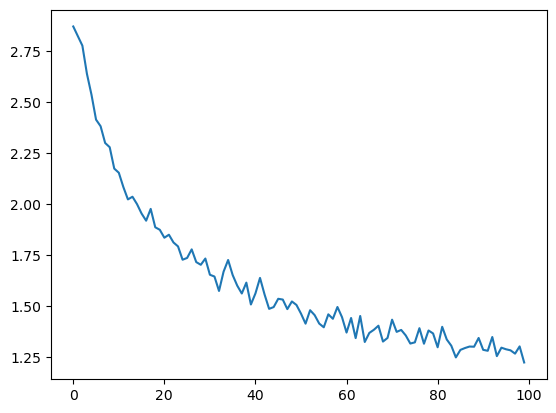

In [141]:
plt.figure()
plt.plot(all_losses)
plt.show()

In [143]:
def predict(input_line):
    print(f"\n> {input_line}")
    with torch.no_grad():
        line_tensor = line_to_tensor(input_line)
        
        hidden = rnn.init_hidden()
    
        for i in range(line_tensor.size()[0]):
            output, hidden = rnn(line_tensor[i], hidden)
        
        guess = category_from_output(output)
        print(guess)

In [145]:
while True:
    sentence = input("Input:")
    if sentence == "quit":
        break
    
    predict(sentence)

Input: Kowalski



> Kowalski
Polish


Input: quit
